# **RAG 구축하기_벡터DB 구성과 RAG 파이프라인 구축2 : 다양한 방법들**

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(langchain)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [4]:
!pip install langchain langchain-community langchain-openai chromadb tiktoken pymupdf faiss-cpu -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 762.7 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 90.7 MB/s eta 0:

#### 2) 라이브러리 로딩

In [5]:
import pandas as pd
import numpy as np
import os
import openai

from langchain.document_loaders import PyMuPDFLoader
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import Chroma
from langchain.chains import RetrievalQA
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage, AIMessage
from langchain.chains import ConversationalRetrievalChain
from langchain.memory import ConversationBufferMemory, ConversationSummaryBufferMemory
from langchain.schema import Document

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### (3) OpenAI API Key 등록
* 환경변수로 key 등록

In [6]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/langchain/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [7]:
print(os.environ['OPENAI_API_KEY'][:40])

sk-proj-9_V5Db5A_3EzpkFeDNheztR-ns32fKi-


## 2.Vector DB 구성

### (1) Loader

#### 1) PDF loader
- PDFLoader는 LangChain에서 PDF 문서를 불러와 RAG 시스템에 사용할 수 있도록 변환하는 도구
- 텍스트 추출 후, 벡터화하여 검색 가능하도록 만듬


In [10]:
from langchain.document_loaders import PyMuPDFLoader

# PDF 파일 로드
pdf_path = "2025년 사이버 위협 전망 보고서.pdf"
pdf_loader = PyMuPDFLoader(path + pdf_path)

# 문서 로드 실행
documents_pdf = pdf_loader.load()

# 출력 확인
print(f"총 {len(documents_pdf)} 개의 페이지가 로드됨")

총 22 개의 페이지가 로드됨


* 실습
    * documents_pdf를 열어 구조를 살펴봅시다.
    * type
    * 길이
    * 열 번 째 값
        * metadata
        * page_content

In [11]:
print(type(documents_pdf))
print(len(documents_pdf))

<class 'list'>
22


In [12]:
i = 9
documents_pdf[i]

Document(metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.0 (Windows)', 'creationdate': '2024-12-17T16:24:24+09:00', 'source': '/content/drive/MyDrive/langchain/2025년 사이버 위협 전망 보고서.pdf', 'file_path': '/content/drive/MyDrive/langchain/2025년 사이버 위협 전망 보고서.pdf', 'total_pages': 22, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-12-17T16:24:31+09:00', 'trapped': '', 'modDate': "D:20241217162431+09'00'", 'creationDate': "D:20241217162424+09'00'", 'page': 9}, page_content='랜섬웨어는 전 세계 모든 국가와 산업에 심각한 영향을 미치는 사이버 범죄이다. 랜섬웨어 \n그룹의 경제적 동기(높은 수익성, 투자수익률(ROI) 등)는  랜섬웨어가 효과적인 사이버 \n공격기법으로 여전히 활용될 수 있는 기반이 되고 있으며, 보안 장비 탐지 우회와 ① 데이터 \n암호화에 그치지 않고, ② 기업의 기밀 자료를 유출하고 공개를 협박하며, ③ 피해 기업에 대해 \n디도스(DDoS) 공격 등 3중 갈취 전술을 사용하는 고도화된 공격 기법으로 기업과 이용자들을 \n압박하고 있다. \n• \x071분기 랜섬웨어 공격 23% 증가... 보안 시스템 우회·합법적 도구 악용 증가(5월)\n• \x01해커 “법무법인 해킹 후, 탈취한 고객정보 공개 협박” 비트코인 요구(9월) \n• \x01상반기 랜섬웨어 피해 비용 평균 20억···진입장벽 낮아지고 방식 고도화(11월)\n주요 사고 사례 및 동향\

In [13]:
documents_pdf[i].metadata

{'producer': 'Adobe PDF Library 17.0',
 'creator': 'Adobe InDesign 20.0 (Windows)',
 'creationdate': '2024-12-17T16:24:24+09:00',
 'source': '/content/drive/MyDrive/langchain/2025년 사이버 위협 전망 보고서.pdf',
 'file_path': '/content/drive/MyDrive/langchain/2025년 사이버 위협 전망 보고서.pdf',
 'total_pages': 22,
 'format': 'PDF 1.7',
 'title': '',
 'author': '',
 'subject': '',
 'keywords': '',
 'moddate': '2024-12-17T16:24:31+09:00',
 'trapped': '',
 'modDate': "D:20241217162431+09'00'",
 'creationDate': "D:20241217162424+09'00'",
 'page': 9}

In [14]:
print(documents_pdf[i].page_content)

랜섬웨어는 전 세계 모든 국가와 산업에 심각한 영향을 미치는 사이버 범죄이다. 랜섬웨어 
그룹의 경제적 동기(높은 수익성, 투자수익률(ROI) 등)는  랜섬웨어가 효과적인 사이버 
공격기법으로 여전히 활용될 수 있는 기반이 되고 있으며, 보안 장비 탐지 우회와 ① 데이터 
암호화에 그치지 않고, ② 기업의 기밀 자료를 유출하고 공개를 협박하며, ③ 피해 기업에 대해 
디도스(DDoS) 공격 등 3중 갈취 전술을 사용하는 고도화된 공격 기법으로 기업과 이용자들을 
압박하고 있다. 
• 1분기 랜섬웨어 공격 23% 증가... 보안 시스템 우회·합법적 도구 악용 증가(5월)
• 해커 “법무법인 해킹 후, 탈취한 고객정보 공개 협박” 비트코인 요구(9월) 
• 상반기 랜섬웨어 피해 비용 평균 20억···진입장벽 낮아지고 방식 고도화(11월)
주요 사고 사례 및 동향
• 파일 암호화, 기밀 자료 유출·공개, 디도스 공격 등 랜섬웨어 그룹 3중 갈취 전술 사용
• 피해 시스템 내부의 합법적 자원(SW)을 공격에 악용하는 자급자족(LoTL) 기법 사용
2024년 사이버 위협 사례 분석
랜섬 공격기법 고도화,  
고객 정보 빌미로 삼중 갈취 공격 지속
3
Cyber Security Forecast 2025
05
사이버 위협 전망


#### 2) csv 로더
- 각 행을 하나의 Document 객체로 변환


In [19]:
data = pd.read_csv(path+'sample.csv')
data.head()

,구분,내용
0,낯선 라이선스 약관,현재 오픈소스 AI 라이선스 유형은 다양한 만큼 매우 복잡하다. 오픈소스 AI 모델...
1,낯선 라이선스 약관,메타와 유사하게 애플은 ‘애플 샘플 코드 라이선스’하에 오픈ELM을 출시했다. 이 ...
2,전문성 부족,오픈소스는 스스로 해야 하는 작업이 많을 수 있다. 기업은 코드를 다운로드할 수는 ...
3,전문성 부족,업계 전체에 전문성이 부족하다는 점은 새로운 문제를 야기한다. 원래 오픈소스의 장점...
4,탈옥,LLM 공격 중 유명한 것에 탈옥(jailbreak)이라는 수법이 있다. 탈옥은 의...


In [20]:
from langchain.document_loaders import CSVLoader

# CSV 파일 로드
csv_path = "sample.csv"
csv_loader = CSVLoader(file_path= path + csv_path)

# 문서 로드 실행
documents_csv = csv_loader.load()

# 첫 번째 행 출력
print(f"총 {len(documents_csv)} 개의 행이 로드됨")
print(documents_csv[0].page_content)
print(documents_csv[0].metadata)

총 13 개의 행이 로드됨
﻿구분: 낯선 라이선스 약관
내용: 현재 오픈소스 AI 라이선스 유형은 다양한 만큼 매우 복잡하다. 오픈소스 AI 모델을 이용하려면 상업적으로 사용해도 괜찮은지, 수정 및 배포가 가능한지, 사내 코드 베이스에 안전하게 통합할 수 있는지 등을 알아봐야 한다. 여기에 몇 가지 새로운 문제가 등장했다. 일단 이전에는 볼 수 없는 제약이 오픈소스 라이선스에 적용됐다.
메타의 라마(Llama) 라이선스를 예로 보자. 라마는 높은 인기를 자랑하는 오픈소스 LLM이다. 메타는 라마에 대해 ‘개방형 접근권을 제공하고 잠재적인 오용 문제를 해결하기 맞춤형 상용 라이선스 모델’을 적용한다고 밝혔다. 또한 이에 대해 ‘책임 및 보호 조치의 균형을 맞추기 위한 조치’라고 소개하고 있다.
이런 라이선스 하에 기업은 상업적으로 라마 모델을 사용할 수 있고 개발자는 기본 라마 모델 위에 추가 작업을 만들어 배포할 수 있다. 단 다른 LLM을 개선하기 위해 라마가 출력하는 결과물을 활용할 수는 없다. (라마 파생 모델은 제외된다.) 또한 기업 또는 그 계열사의 월간 사용자가 700명을 초과하는 경우, 메타에게 라이선스 사용 허락을 요청해야 한다. 메타는 이를 승인하거나 승인하지 않을 수 있다. 어떤 기업에서 라마 3를 사용해서 뭔가를 만들었다면, 눈에 잘 띄는 위치에 ‘Built with Llama 3(라마 3를 기반으로 구축했음)’라는 문구를 표기해야 한다.
{'source': '/content/drive/MyDrive/langchain/sample.csv', 'row': 0}


### (2) Splitter

In [21]:
from langchain.text_splitter import CharacterTextSplitter

In [22]:
text_splitter = CharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap  = 100,
    separator = '\n',   # \n 줄바꿈 문자 기준으로 자르기,
)

split_docs = text_splitter.split_documents(documents_pdf)
print(f"원본 문서 개수: {len(documents_pdf)}")
print(f"분할된 청크 개수: {len(split_docs)}")
print(f"첫 번째 청크:\n{split_docs[0].page_content}")

원본 문서 개수: 22
분할된 청크 개수: 41
첫 번째 청크:
사이버 위협 전망
Cyber Security Forecast 2025


In [23]:
split_docs[4].page_content

'② 디지털 융합 확산, 우크라이나-러시아 전쟁 등 ③ 글로벌 환경 변화와 관련된 사이버 위협 및 \n꾸준히 지속되고 있는 ④ 분산 서비스 거부(DDoS) 공격을 선정하였다.\n * \x01최신 사이버 위협 정보공유 및 침해사고 공동 대응을 위해 KISA와 국내ㆍ외 보안업체가 운영하고 있는 협력 네트워크\n  • (국내) 안랩, 지니언스, 이글루코퍼레이션, NSHC, S2W, SK쉴더스, 플레인비트\n  • (해외) Cisco Talos, Google, Microsoft, Splunk, Trend Micro, Zscaler\n본 보고서를 통해 기업 보안 담당자들은 앞으로도 지속될 사이버 위협에 대해 다시 한 번 내부 보안 \n상황을 재점검 해보고 다가 올 위협에 체계적인 보안관리와 선제적인 대응 방안을 수립하여 피해 \n예방에 도움이 될 수 있기를 기대한다.\n사이버 보안 위협 \n분석과 전망'

### (3) Embedding & Store

#### 1) Embedding model 선언

In [24]:
from langchain.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

#### 2) FAISS DB 저장
- FAISS : FAISS(Facebook AI Similarity Search)는 Facebook AI Research에 의해 개발된 라이브러리

**(참고) Chroma vs. FAISS**
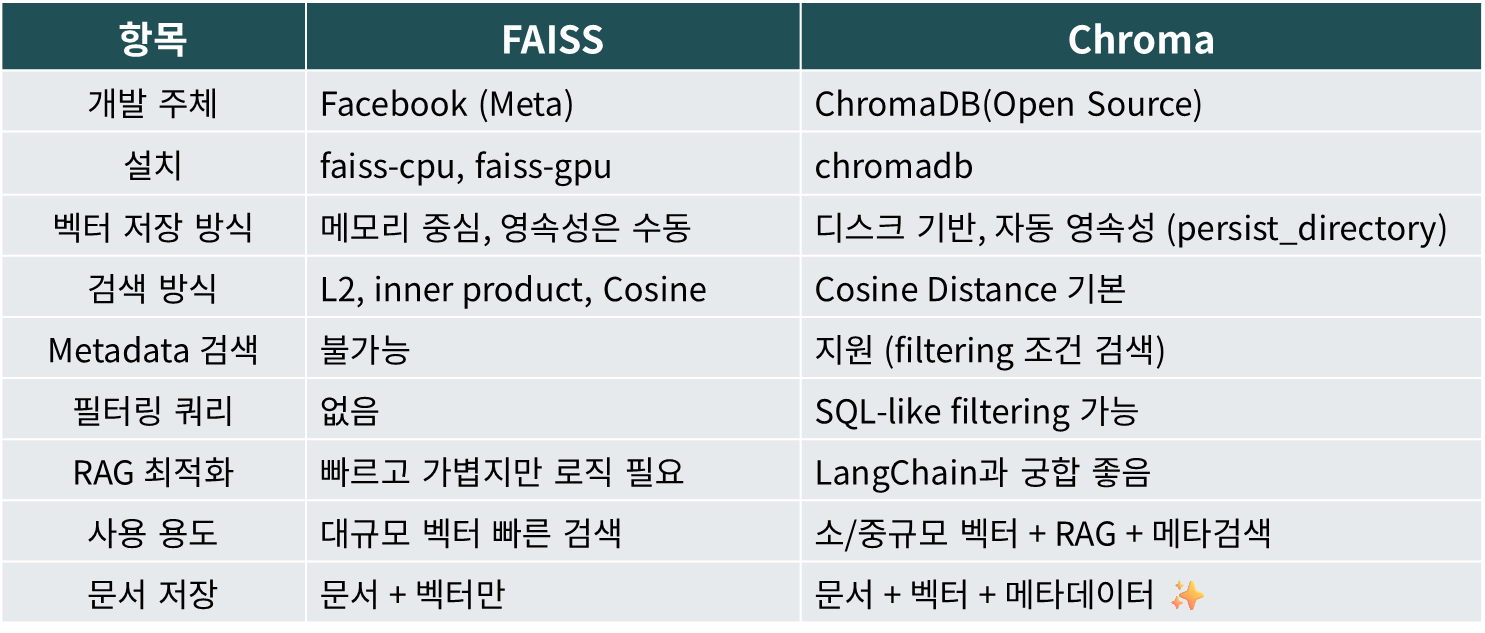

In [25]:
from langchain.vectorstores import FAISS

vectorstore = FAISS.from_documents(split_docs, embedding_model)
vectorstore.save_local("faiss_index")  # 'faiss_index' 폴더에 저장됨

In [26]:
vectorstore

* 저장된 벡터DB 로딩하기

In [27]:
# 저장된 벡터DB를 로딩하기
new_vectorstore = FAISS.load_local(
    "faiss_index",
    embedding_model,
    allow_dangerous_deserialization=True
)

#### 3) DB에 추가 입력

In [28]:
new_docs = [
    Document(page_content="조선시대의 교육 제도는 성균관 중심이었다.", metadata={"source": "추가"}),
    Document(page_content="한국 전통 사회에서 글을 읽는 능력은 권력의 상징이었다.", metadata={"source": "추가"})
]

# 문서 추가
vectorstore.add_documents(new_docs)

['4f09395f-7b74-4dcb-a7d6-d29db36e9f62',
 'cad09d4b-0aa1-49ca-878d-e8e04b688a73']

#### 4) 저장된 문서 전부 조회

In [29]:
all_docs = new_vectorstore.docstore._dict  # 내부에 저장된 모든 문서

for i, (doc_id, doc) in enumerate(all_docs.items()):
    print(f"[{i+1}] 문서 ID: {doc_id}")
    print(doc.page_content[:300])  # 300자까지만 보기
    print("-" * 50)

[1] 문서 ID: 514e52e0-b471-4027-81c0-02d9e520faab
사이버 위협 전망
Cyber Security Forecast 2025
--------------------------------------------------
[2] 문서 ID: a8380b73-656e-4def-8946-32fc175ab267
1. 2024년 사이버 위협 사례 분석
 1 /   사이버 사기로 인한 국민 불편 및 금융피해 지속
 2 /  SW 공급망 공격은 기본, 복합적인 공격 전술 사용
 3 /  랜섬 공격기법 고도화, 고객 정보 빌미로 삼중 갈취 공격 지속
2. 2025년 사이버 위협 전망
1 /  공격자의 생성형 AI 활용 본격화
2 /  디지털 융복합 시스템에 대한 사이버 위협 증가 예상
3 /  글로벌 환경 변화에 따른 사이버 위협 증가 가능성
4 /  무차별 디도스 공격 증가 예상
사이버 위협 전망
Cyber Security Fore
--------------------------------------------------
[3] 문서 ID: 85e10b8a-7ff6-4f27-ace8-907d841dbfa0
공격자의 생성형 AI 활용 본격화
글로벌 환경 변화에 따른 사이버 위협 증가 가능성
디지털 융복합 시스템에 대한 사이버 위협 증가 예상
무차별 디도스 공격 증가 예상
DDoS
1
3
2
4
2025년 사이버 위협 전망
사이버 사기로 인한  
국민 불편 및 금융피해 지속
SW 공급망 공격은 기본, 
복합적인 공격 전술 사용
랜섬 공격기법 고도화, 고객  
정보 빌미로 삼중 갈취 공격 지속
1
2
3
2024년 사이버 위협 사례 분석
--------------------------------------------------
[4] 문서 ID: a933da26-9f53-4222-8b79-c6d1845675b4
국가의 지원을 받는 해킹그룹의 활동 증가, 생성형 인공지능의 악용 가능성 증가 등 최근 사이버 
위협은 더욱 지능화, 고도화되고 

### (4) 유사도 검색

* 유사도 높은 문서 조회

In [30]:
query = "가장 심각한 사이버 보안 위험이 뭐야?"
retrieved_docs = vectorstore.similarity_search(query, k=3)

# 결과 출력
print("검색 결과:")
for doc in retrieved_docs:
    print(doc.page_content)
    print('-'*200)

검색 결과:
따라서 스마트시티, 디지털 융복합 시스템 및 서비스, IoT 기기 등에 대한 설계 및 개발 
단계에서부터 사이버 위협으로부터 보호할 수 있는 보안을 내재화하여 안전한 운영 환경을 
보장할 필요가 있다. 또한, 운영 중인 디지털 제품 및 서비스의 외부 접점을 지속적으로 
모니터링하는 공격 표면 관리(ASM, Attack, Surface, Management)가 필수적이다. 
사용자는 IoT 기기의 보안 설정을 강화하고, 보안 인증을 받은 기기를 사용하는 노력이 
필요하다.
11
사이버 위협 전망
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
② 디지털 융합 확산, 우크라이나-러시아 전쟁 등 ③ 글로벌 환경 변화와 관련된 사이버 위협 및 
꾸준히 지속되고 있는 ④ 분산 서비스 거부(DDoS) 공격을 선정하였다.
 * 최신 사이버 위협 정보공유 및 침해사고 공동 대응을 위해 KISA와 국내ㆍ외 보안업체가 운영하고 있는 협력 네트워크
  • (국내) 안랩, 지니언스, 이글루코퍼레이션, NSHC, S2W, SK쉴더스, 플레인비트
  • (해외) Cisco Talos, Google, Microsoft, Splunk, Trend Micro, Zscaler
본 보고서를 통해 기업 보안 담당자들은 앞으로도 지속될 사이버 위협에 대해 다시 한 번 내부 보안 
상황을 재점검 해보고 다가 올 위협에 체계적인 보안관리와 선제적인 대응 방안을 수립하여 피해 
예방에 도움이 될 수 있기를 기대한다.
사이버 보안 위협 
분석과 전망
----------------------------------------------------------------------------

* 유사도 점수도 함께 조회

In [31]:
# 검색
query = "랜섬웨어 대응 방안은?"
retrieved_docs = vectorstore.similarity_search_with_score(query, k=2)

# 점수 추출 + 변환
for doc, score in retrieved_docs:
    print('유사도 점수 :', score)
    print('문서 내용 :', doc.page_content)
    print('-'*200)

유사도 점수 : 1.0138664
문서 내용 : 것을 의미
랜섬웨어는 공격자들은 피해 기업의 이해 관계자(협력사, 고객 등)와 직접 접촉하여 랜섬웨어 
피해 사실을 알리고, 유출된 정보를 이용해 추가적으로 몸값을 요구한다. 이로 인해 피해 기업의 
평판과 신뢰도가 심각하게 훼손되며, 랜섬웨어의 피해 범위는 제3자에게까지 확산될 수 있다. 
랜섬웨어 공격에 대비하기 위해 각 기업은 공격 표면 관리(ASM, Attack Surface 
Management), 내부 시스템 보안 점검, 백업 등을 강화해야 한다. 또한, 내부 시스템이나 
단말기에 저장된 민감한 고객 정보(예: 환자 정보, 의뢰서, 계약서 등)에 대한 안전 조치를 
점검하고 강화하는 것이 필수적이다. 이를 통해 공격에 대한 취약점을 최소화하고, 데이터 
유출이나 손상을 방지할 수 있다.
KISA는 랜섬웨어 대응 역량이 부족한 지역․ 중소․ 영세기업을 대상으로 무상 보안취약점 점검과
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
유사도 점수 : 1.1400156
문서 내용 : 2024년 사이버 위협 사례 분석
또한 최근 랜섬웨어는 피해 시스템 내부의 합법적인 자원(SW)을 공격에 악용하는 
LoTL(Living off the Land)* 기법도 사용하고 있다. LoTL 기법은 윈도우나 유닉스 
운영체제에서 기본적으로 제공하는 SW를 악용함으로써 정상적으로 발생하는 트래픽과 
공격자의 트래픽 구분을 어렵게 만들며, 내부 시스템으로의 전파 및 횡적이동(Lateral 
Movement)** 시 보안 장비의 탐지 우회 가능성을 높여 공격 지속 시간을 연장시킨다.
    * 자급자족 공격으로도 불리며, 

In [32]:
# 예: 임계값 0.25 이하인 문서만 필터링
threshold = 0.3
query = "랜섬웨어 대응 방안은?"

# # 검색
# retrieved_docs = vectorstore.similarity_search_with_score(query, k=2)

# # 점수 추출 + 변환
# doc, score_np = retrieved_docs[0]

def filtered_faiss_search(query, threshold=threshold, k=3):
    results = vectorstore.similarity_search_with_score(query, k=k)
    return [doc for doc, score in results if score <= threshold]

# 사용 예시
docs = filtered_faiss_search(query)
docs

[]

* 실습 :
몇가지 질문을 하고 유사도 높은 문서가 잘 조회되는지 확인해 봅시다.

In [33]:
query = "사이버 보안 체계를 강화하는 방법은?"
retrieved_docs = vectorstore.similarity_search(query, k=3)

# 결과 출력
print("검색 결과:")
for doc in retrieved_docs:
    print(doc.page_content)
    print('-'*200)

검색 결과:
것으로 보인다. 기업들은 사이버 보안 체계를 상시 점검하고 협력사의 보안 역량을 강화하여 
대응 능력을 높여야 한다. 아울러, 국가안보실을 중심으로 민·관·군이 협력하여 공세적 방어 
체계와 사이버 억지 전략을 통해 사회적 혼란을 최소화해야 한다.
13
사이버 위협 전망
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
따라서 스마트시티, 디지털 융복합 시스템 및 서비스, IoT 기기 등에 대한 설계 및 개발 
단계에서부터 사이버 위협으로부터 보호할 수 있는 보안을 내재화하여 안전한 운영 환경을 
보장할 필요가 있다. 또한, 운영 중인 디지털 제품 및 서비스의 외부 접점을 지속적으로 
모니터링하는 공격 표면 관리(ASM, Attack, Surface, Management)가 필수적이다. 
사용자는 IoT 기기의 보안 설정을 강화하고, 보안 인증을 받은 기기를 사용하는 노력이 
필요하다.
11
사이버 위협 전망
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
② 디지털 융합 확산, 우크라이나-러시아 전쟁 등 ③ 글로벌 환경 변화와 관련된 사이버 위협 및 
꾸준히 지속되고 있는 ④ 분산 서비스 거부(DDoS) 공격을 선정하였다.
 * 최신 사이버 위협 정보공유 및 침해사고 공동 대응을 위해 KISA와 국내ㆍ외 보안업체가 운영하고 있는 협력 

In [34]:
docs

[]

### (5) 실습
documents_csv를 벡터DB로 저장시키기

* loader : 이미 수행됨 : documents_csv
* splitter : 한 행을 하나의 chunk로 지정하는 것이라면, 별도 split 필요 없음.
* documents_csv 를 faiss db에 저장하기
    * documents_csv 를 그대로 입력
    * db name : vector_db_csv
    * 파일로 저장.
    * 전체 데이터 조회
* 두개의 문서를 추가한다.
    * 문서1
        * 구분 : 지적재산권
        * 내용 : 여기에 지적재산권 문제도 있다. 누구나 사용할 수 있도록 만들어진 것이 오픈소스 소프트웨어지만 세밀하게 들여다보면 각 소프트웨어 별로 라이선스가 다르다. 재배포를 허용하는 것도 있고 아닌것도 있으며 하나의 소프트웨어만 작동할 때는 무료지만 다른 기능을 사용하려면 유료로 전환되는 것도 있다.
    * 문서2
        * 구분 : 보안
        * 내용 : 개개인이 분산 방식으로 협업하는 오픈소스는 보안이 취약한 분야가 생길 가능성이 크다. 그리고 이를 악용하는 개발자도 당연히 있을 수 있다. 그리고 오픈소스를 사용해 프로그램을 만들면 참고한 오픈소스에 종속되는 경우가 많기에 오픈소스에 문제가 생기면 프로그램 자체에 중대한 오류가 발생할 가능성이 높다는 위험이 있다.
* 유사도 검색 시도하기

In [35]:
# DB 저장
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
vector_db_csv = FAISS.from_documents(documents_csv, embedding_model)
vectorstore.save_local("faiss_csv_index")

In [36]:
all_docs = vector_db_csv.docstore._dict  # 내부에 저장된 모든 문서

for i, (doc_id, doc) in enumerate(all_docs.items()):
    print(f"[{i+1}] 문서 ID: {doc_id}")
    print(doc.page_content[:300])  # 300자까지만 보기
    print(doc.metadata)
    print("-" * 50)

[1] 문서 ID: 221a68c0-5a98-4f21-9198-5cea1ac6008e
﻿구분: 낯선 라이선스 약관
내용: 현재 오픈소스 AI 라이선스 유형은 다양한 만큼 매우 복잡하다. 오픈소스 AI 모델을 이용하려면 상업적으로 사용해도 괜찮은지, 수정 및 배포가 가능한지, 사내 코드 베이스에 안전하게 통합할 수 있는지 등을 알아봐야 한다. 여기에 몇 가지 새로운 문제가 등장했다. 일단 이전에는 볼 수 없는 제약이 오픈소스 라이선스에 적용됐다.
메타의 라마(Llama) 라이선스를 예로 보자. 라마는 높은 인기를 자랑하는 오픈소스 LLM이다. 메타는 라마에 대해 ‘개방형 접근권을 제공하고 잠재적인 오용 문제를 해결하기
{'source': '/content/drive/MyDrive/langchain/sample.csv', 'row': 0}
--------------------------------------------------
[2] 문서 ID: b5b81cf5-3658-4b80-af68-21f29bca4b89
﻿구분: 낯선 라이선스 약관
내용: 메타와 유사하게 애플은 ‘애플 샘플 코드 라이선스’하에 오픈ELM을 출시했다. 이 라이선스 역시 특허권은 제외하고 저작권 권한만 명시하고 있다. 애플이나 메타 모두 일반적으로 통용되는 오픈소스 라이선스를 사용하지는 않지만, 실제로 코드는 공개되어 있다. 여기에 애플은 실제로 코드뿐만 아니라 모델 가중치, 훈련 데이터 세트, 훈련 로그, 사전 훈련 구성도 공개했다.
이제 오픈소스 라이선스의 또 다른 측면을 살펴보자. 기존의 오픈소스 소프트웨어에서 핵심은 ‘코드’였다. 그리고 그 코드를 통해 소프트웨
{'source': '/content/drive/MyDrive/langchain/sample.csv', 'row': 1}
--------------------------------------------------
[3] 문서 ID: 6de7e6eb-f1f8-4dc3-8be8-d7c2eaa80545
﻿구분: 전문성 부족
내용: 

In [37]:
doc1 = '''구분 : 지적재산권
내용 : 여기에 지적재산권 문제도 있다. 누구나 사용할 수 있도록 만들어진 것이 오픈소스 소프트웨어지만 세밀하게 들여다보면 각 소프트웨어 별로 라이선스가 다르다. 재배포를 허용하는 것도 있고 아닌것도 있으며 하나의 소프트웨어만 작동할 때는 무료지만 다른 기능을 사용하려면 유료로 전환되는 것도 있다.
'''
doc2 = '''구분 : 보안
내용 : 개개인이 분산 방식으로 협업하는 오픈소스는 보안이 취약한 분야가 생길 가능성이 크다. 그리고 이를 악용하는 개발자도 당연히 있을 수 있다. 그리고 오픈소스를 사용해 프로그램을 만들면 참고한 오픈소스에 종속되는 경우가 많기에 오픈소스에 문제가 생기면 프로그램 자체에 중대한 오류가 발생할 가능성이 높다는 위험이 있다.
'''
new_docs = [
    Document(page_content=doc1, metadata={"source": "추가"}),
    Document(page_content=doc2, metadata={"source": "추가"})
]

# 문서 추가
vector_db_csv.add_documents(new_docs)

['144a59d5-e41f-4566-8f3c-b54bc0dd27df',
 '335a8136-5f1d-46b5-a1af-0996c54f0857']

In [38]:
all_docs = vector_db_csv.docstore._dict  # 내부에 저장된 모든 문서

for i, (doc_id, doc) in enumerate(all_docs.items()):
    print(f"[{i+1}] 문서 ID: {doc_id}")
    print(doc.page_content[:300])  # 300자까지만 보기
    print(doc.metadata)
    print("-" * 50)

[1] 문서 ID: 221a68c0-5a98-4f21-9198-5cea1ac6008e
﻿구분: 낯선 라이선스 약관
내용: 현재 오픈소스 AI 라이선스 유형은 다양한 만큼 매우 복잡하다. 오픈소스 AI 모델을 이용하려면 상업적으로 사용해도 괜찮은지, 수정 및 배포가 가능한지, 사내 코드 베이스에 안전하게 통합할 수 있는지 등을 알아봐야 한다. 여기에 몇 가지 새로운 문제가 등장했다. 일단 이전에는 볼 수 없는 제약이 오픈소스 라이선스에 적용됐다.
메타의 라마(Llama) 라이선스를 예로 보자. 라마는 높은 인기를 자랑하는 오픈소스 LLM이다. 메타는 라마에 대해 ‘개방형 접근권을 제공하고 잠재적인 오용 문제를 해결하기
{'source': '/content/drive/MyDrive/langchain/sample.csv', 'row': 0}
--------------------------------------------------
[2] 문서 ID: b5b81cf5-3658-4b80-af68-21f29bca4b89
﻿구분: 낯선 라이선스 약관
내용: 메타와 유사하게 애플은 ‘애플 샘플 코드 라이선스’하에 오픈ELM을 출시했다. 이 라이선스 역시 특허권은 제외하고 저작권 권한만 명시하고 있다. 애플이나 메타 모두 일반적으로 통용되는 오픈소스 라이선스를 사용하지는 않지만, 실제로 코드는 공개되어 있다. 여기에 애플은 실제로 코드뿐만 아니라 모델 가중치, 훈련 데이터 세트, 훈련 로그, 사전 훈련 구성도 공개했다.
이제 오픈소스 라이선스의 또 다른 측면을 살펴보자. 기존의 오픈소스 소프트웨어에서 핵심은 ‘코드’였다. 그리고 그 코드를 통해 소프트웨
{'source': '/content/drive/MyDrive/langchain/sample.csv', 'row': 1}
--------------------------------------------------
[3] 문서 ID: 6de7e6eb-f1f8-4dc3-8be8-d7c2eaa80545
﻿구분: 전문성 부족
내용: 

In [39]:
# 유사도 검색
query = "지적재산권 관련 문제는?"
retrieved_docs = vector_db_csv.similarity_search(query, k=3)

# 결과 출력
print("검색 결과:")
for doc in retrieved_docs:
    print(doc.page_content)
    print('-'*200)

검색 결과:
구분 : 지적재산권
내용 : 여기에 지적재산권 문제도 있다. 누구나 사용할 수 있도록 만들어진 것이 오픈소스 소프트웨어지만 세밀하게 들여다보면 각 소프트웨어 별로 라이선스가 다르다. 재배포를 허용하는 것도 있고 아닌것도 있으며 하나의 소프트웨어만 작동할 때는 무료지만 다른 기능을 사용하려면 유료로 전환되는 것도 있다.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
구분 : 보안
내용 : 개개인이 분산 방식으로 협업하는 오픈소스는 보안이 취약한 분야가 생길 가능성이 크다. 그리고 이를 악용하는 개발자도 당연히 있을 수 있다. 그리고 오픈소스를 사용해 프로그램을 만들면 참고한 오픈소스에 종속되는 경우가 많기에 오픈소스에 문제가 생기면 프로그램 자체에 중대한 오류가 발생할 가능성이 높다는 위험이 있다.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
﻿구분: 누락된 가드레일
내용: 오픈소스 그룹 일각에서는 AI 모델에 가드레일(허용 가능한 범위를 두는 일종의 가이드라인 또는 도구)을 두는 것 자체를 반대하기도 한다. 모델에 아무런 제한 없어야 더 나은 성능을 발휘할 것이라 믿는 곳도 있다. 기업은 현재 사용하는 오픈소스 모델이 가드레일에 대해 어떤 방향을 추구하는지조차 잘 모를 수도 있다.
수기스는 “현재 오픈소스 생성형 AI 모델의 안

## 3.RAG 파이프라인

* 순서
    * (1) Retriever 선언
    * (2) llm 모델 지정
    * (3) 메모리 선언
    * (4) 체인 함수로 엮기

### (1) RAG 파이프라인 구축

In [40]:
# (1) 리트리버(Retriever) 생성
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# (2) GPT-4.1-mini 모델 설정
llm = ChatOpenAI(model_name="gpt-4.1-mini")

# (3) 메모리 추가 (대화 문맥 유지)
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True, output_key="answer")

# (4) RAG 기반 ConversationalRetrievalChain 구성
qa_chain = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,
    memory=memory,
    return_source_documents=False  # 검색된 문서 출력 옵션
)

### (2) RAG 파이프라인 사용

In [41]:
# 테스트 실행
query = "사이버 위협 요인중 가장 중요한게 뭐야??"
response = qa_chain({"question": query})

# 응답 출력
print("답변:", response["answer"])

답변: 사이버 위협 요인 중 가장 중요한 것으로는 "공격자의 생성형 AI 활용 본격화"가 꼽힙니다. 2025년 전망에 따르면, 공격자들이 생성형 AI를 적극 활용하여 더욱 정교하고 고도화된 공격을 시도할 것으로 예상되기 때문입니다. 이 외에도 디지털 융복합 시스템에 대한 위협 증가, 글로벌 환경 변화에 따른 위협 증가, 무차별 디도스 공격 증가 등이 중요한 사이버 위협 요인으로 지목되고 있습니다.


### (3) 프롬프트 템플릿 활용하기

In [42]:
from langchain.prompts import ChatPromptTemplate

# 프롬프트 템플릿
prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 사이버 보안 분야 최고 전문가야. 답변은 간결하게 해줘."),
    ("human", "질문: {question}\n\n관련 문서:\n{context}")
])

# 체인 구성
qa_chain = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,
    memory=memory,
    combine_docs_chain_kwargs={"prompt": prompt},
    return_source_documents=True,
)


In [43]:
# 테스트 실행
query = "랜섬웨어 공격 시 어떻게 대응해야 하나요?"
response = qa_chain({"question": query})

# 응답 출력
print("답변:", response["answer"])

답변: 랜섬웨어 공격 대응법:
1. 공격 표면 관리(ASM) 강화로 취약점 최소화.
2. 내부 시스템 및 단말기 보안 점검 및 강화.
3. 민감 정보(고객, 환자 데이터 등) 안전 조치 철저.
4. 정기적 백업 및 신속 복구 체계 구축.
5. LoTL 기법 등 탐지 우회 공격 대비, 이상 징후 모니터링 강화.
6. 보안 취약점 점검 및 전문기관 지원 활용.
7. 공격 발생 시, 3중 갈취(암호화·유출·DDoS) 대응 전략 마련.
8. 협력사·고객 커뮤니케이션 체계 구축해 평판 피해 최소화.


## **4. 실습**

### (1) Loader
* '생성형_AI윤리_가이드북.pdf' 파일을 로딩하여 doc_ethics 에 저장합니다.
* doc_pdf를 열어 구조를 살펴봅시다.
    * type
    * 길이
    * 특정 페이지
        * metadata
        * page_content

In [44]:
# PDF 파일 로드
pdf_path = "생성형_AI윤리_가이드북.pdf"
pdf_loader = PyMuPDFLoader(path + pdf_path)

# 문서 로드 실행
doc_ethics = pdf_loader.load()

# 출력 확인
print(f"총 {len(doc_ethics)} 개의 페이지가 로드됨")

총 74 개의 페이지가 로드됨


In [45]:
print(type(doc_ethics))
print(len(doc_ethics))

<class 'list'>
74


In [46]:
i = 9
doc_ethics[i]

Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2023-12-20T13:45:08+09:00', 'source': '/content/drive/MyDrive/langchain/생성형_AI윤리_가이드북.pdf', 'file_path': '/content/drive/MyDrive/langchain/생성형_AI윤리_가이드북.pdf', 'total_pages': 74, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2023-12-20T13:46:11+09:00', 'trapped': '', 'modDate': "D:20231220134611+09'00'", 'creationDate': "D:20231220134508+09'00'", 'page': 9}, page_content='08\n생성형 AI윤리 가이드북\nPART\n생성형 AI란?\n01\n생성형 AI가 무엇일까요?\n생성형 AI(Generative AI)란, 대규모 데이터와 패턴을 학습하고 기존의 데이터를 활용하여 이용자의 요구에 \n따라 텍스트, 이미지, 비디오, 음악, 코딩 등 새로운 결과를 만들어 내는 인공지능 기술입니다. 생성형 AI는 \n누구나 쉽게 활용할 수 있도록 설계되었고, 굉장히 다양한 영역에서 유용하게 활용될 수 있기 때문에 인공지능 \n분야의 새로운 화두가 되었습니다. \n지난 2016년에 구글 딥마인드(Google DeepMind)가 개발한 인공지능 바둑프로그램인 알파고(AlphaGo)와 \n이세돌 9단의 바둑 대결은 인공지능과 인간의 대결이라는 타이틀로 모두에게 놀라움을 안겼습니다. 그런데 \n실제로 많은 사람들이 직접 경험하거나 체감할 수 없는 부분이기 때문에 차츰 잊혀져 갔습니다. 그러다가 \n2022년

In [47]:
doc_ethics[i].metadata

{'producer': 'Adobe PDF Library 15.0',
 'creator': 'Adobe InDesign 15.0 (Macintosh)',
 'creationdate': '2023-12-20T13:45:08+09:00',
 'source': '/content/drive/MyDrive/langchain/생성형_AI윤리_가이드북.pdf',
 'file_path': '/content/drive/MyDrive/langchain/생성형_AI윤리_가이드북.pdf',
 'total_pages': 74,
 'format': 'PDF 1.6',
 'title': '',
 'author': '',
 'subject': '',
 'keywords': '',
 'moddate': '2023-12-20T13:46:11+09:00',
 'trapped': '',
 'modDate': "D:20231220134611+09'00'",
 'creationDate': "D:20231220134508+09'00'",
 'page': 9}

In [48]:
print(doc_ethics[i].page_content)

08
생성형 AI윤리 가이드북
PART
생성형 AI란?
01
생성형 AI가 무엇일까요?
생성형 AI(Generative AI)란, 대규모 데이터와 패턴을 학습하고 기존의 데이터를 활용하여 이용자의 요구에 
따라 텍스트, 이미지, 비디오, 음악, 코딩 등 새로운 결과를 만들어 내는 인공지능 기술입니다. 생성형 AI는 
누구나 쉽게 활용할 수 있도록 설계되었고, 굉장히 다양한 영역에서 유용하게 활용될 수 있기 때문에 인공지능 
분야의 새로운 화두가 되었습니다. 
지난 2016년에 구글 딥마인드(Google DeepMind)가 개발한 인공지능 바둑프로그램인 알파고(AlphaGo)와 
이세돌 9단의 바둑 대결은 인공지능과 인간의 대결이라는 타이틀로 모두에게 놀라움을 안겼습니다. 그런데 
실제로 많은 사람들이 직접 경험하거나 체감할 수 없는 부분이기 때문에 차츰 잊혀져 갔습니다. 그러다가 
2022년 11월 OpenAI의 생성형 AI 모델 ChatGPT의 등장으로 사람들은 마치 가까운 친구와 편하게 대화를 
나누듯 쉽고, 빠르고, 편리하게 인공지능을 활용할 수 있게 되자 다시금 인공지능에 대한 관심과 기대가 
높아졌습니다.
스태티스타(Statista)의 조사결과 ChatGPT가 사용자 100만명을 확보하는데 걸린 시간은 단 5일이었다고 
합니다. 넷플릭스가 3.5년, 인스타그램이 2.5개월이 걸린 것과 비교하면 굉장히 빠르게 확산된 것이란 걸 알 
수 있습니다.
생성형 AI는 텍스트(ChatGPT, Bard, Bing, 뤼튼, AskUp 등), 이미지(DALL·E 2, Midjourney, Stable 
Diffusion 등), 영상(D-ID, VCAT, Runway, InVideo 등), 음성(클로바더빙, AI보이스 스튜디오, Typecast. 
VoxBox 등), 글쓰기(Notion Al, Magic Write 등), 프로그래밍(GitHub Copilot, Tabnine 등) 등 활용도 
무궁무진합니다.
생성형 AI가 가져온 변화는 무엇일까요?
생성형 AI는 우리 

### (2) Splitter
* doc_ethics 파일을 split 해 봅시다.
    * split 한 내용을 split_ethics에 저장
    * 청크 크기와 오버랩은 직접 결정해 봅시다.

In [49]:
text_splitter = CharacterTextSplitter(
    chunk_size = 300,
    chunk_overlap  = 100,
    separator = '\n',   # \n 줄바꿈 문자 기준으로 자르기,
)

split_ethics = text_splitter.split_documents(doc_ethics)
print(f"원본 문서 개수: {len(doc_ethics)}")
print(f"분할된 청크 개수: {len(split_ethics)}")
print(f"첫 번째 청크:\n{split_ethics[0].page_content}")

원본 문서 개수: 74
분할된 청크 개수: 300
첫 번째 청크:
허위조작정보
가이드북
윤리
생성형
책임성
저작권
개인정보·인격권
오남용


### (3) Embedding & Store
* 벡터DB 이름 : vect_ethics

In [50]:
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
vect_ethics = FAISS.from_documents(split_ethics, embedding_model)

### (4) RAG 파이프라인 구축

* 모델 : gpt-4.1-mini, temperature 조절
* 메모리 : 요약 메모리


In [51]:
# (1) 리트리버(Retriever) 생성
retriever = vect_ethics.as_retriever(search_kwargs={"k": 3})

# (2) GPT-4.1-mini 모델 설정
llm = ChatOpenAI(model_name="gpt-4.1-mini", temperature = 0.2)

# (3) 메모리 추가 (대화 문맥 유지)
memory = ConversationSummaryBufferMemory(llm = llm, memory_key="chat_history", return_messages=True, output_key="answer")

# (4) RAG 기반 ConversationalRetrievalChain 구성
ethci_chat = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,
    memory=memory,
    return_source_documents=False  # 검색된 문서 출력 옵션
)

### (5) RAG 파이프라인 사용

In [52]:
# 테스트 실행
query = "보이스피싱 전화를 받았는데 어떻게 해야 해?"
response = ethci_chat({"question": query})

# 응답 출력
print("답변:", response["answer"])

답변: 보이스피싱 전화를 받았을 때는 다음과 같이 조치하는 것이 중요합니다:

1. **즉시 전화를 끊으세요.** 의심스러운 전화는 더 이상 대화하지 않는 것이 안전합니다.

2. **개인정보나 금융정보를 절대 알려주지 마세요.** 보이스피싱 범죄자들은 이를 이용해 피해를 입힙니다.

3. **피해가 의심되면 즉시 신고하세요.**  
   - 경찰청 사이버수사대  
   - 금융감독원  
   - 거래한 금융회사 고객센터  

4. **금융회사에 연락해 입금·송금 정지를 요청하세요.** 피해 금액이 범인에게 넘어가지 않도록 신속히 조치해야 합니다.

5. **경찰서(사이버 수사대)를 방문해 사건사고 확인원을 발급받아 금융회사에 제출하면 피해금 환급 신청이 가능합니다.**

6. **스마트폰이나 컴퓨터에 보이스피싱 앱이 설치되어 있는지 확인하고, 이상 거래 탐지 시스템이 있는 경우 이를 활용하세요.**

이 외에도, 보이스피싱 피해를 예방하기 위해서는 출처가 불분명한 전화나 메시지에 주의하고, 의심스러운 상황에서는 주변에 도움을 요청하는 것이 좋습니다.
